# Non-Linear Economy Estimation (ANN)

Please note that this notebook uses a venv which points to a base python version of **3.13**, some functionality may be limited if using an older version of python.

## All Imports

In [24]:
%pip install scikit-learn seaborn torch torchvision gymnasium stable-baselines3 --quiet

Note: you may need to restart the kernel to use updated packages.


In [25]:
%matplotlib widget

## Data From Source Package

In [26]:
%pip install -e ../ --quiet

Note: you may need to restart the kernel to use updated packages.


In [27]:
import autonomous_fed as afed

In [28]:
le_solver = afed.LinearEnvironmentSolver(fred_key="7ab121fb17773e187bb6508e83e411da")

# Data Check
print (le_solver.historical_data.head())
print (le_solver.historical_data.tail())

             pi         y     i
date                           
1987Q3  2.66122 -0.388640  6.84
1987Q4  2.91876  0.526730  6.92
1988Q1  3.06577  0.260731  6.66
1988Q2  3.35274  0.788853  7.16
1988Q3  3.80207  0.595530  7.98
             pi         y     i
date                           
2006Q2  3.35642  1.319357  4.91
2006Q3  3.13805  0.978513  5.25
2006Q4  2.66316  1.380249  5.25
2007Q1  2.91019  1.210046  5.26
2007Q2  2.72883  1.336951  5.25


## Model Architecture

### NARX Model

For our economy transition equations we have: ${y_t=\hat{f}^y(y_{t-1},y_{t-2},\pi_t,\pi_{t-1},\pi_{t-2},i_t,i_{t-1},i_{t-2})+\epsilon_t^y}$ and ${\pi_t=\hat{f}^\pi(y_t,y_{t-1},y_{t-2},\pi_{t-1},\pi_{t-2},i_t,i_{t-1},i_{t-2})+\epsilon_t^\pi}$

In this scenario our predictor function, ${\hat{f}}$ is an ANN (Artificial Neural Network) but it can be swapped with other nonlinear functions such as a sigmoid function or wavelet network. For our ANN predictor we have ${\hat{f}^m=b_0^m+\sum_{j=1}^h v_j^mG(\omega_j^{m'}s_t^m+b_j^m), m\in\{y,\pi}\}$

The Components of the ANN are as follows:
- ${m}$: ${\{y,\pi}\}$
- ${s_t^m}$: Input state vectors at time t.
- ${w_j^m}$: Weight vector for the j-th hidden neuron.
- ${b_j^m}$: Bias term for the current neuron.
- ${G(\cdot)}$: Activation function (nonlinear transform).
- ${v_j^m}$: Weight from hidden neuron ${j}$ to the output layer
- ${b_0^m}$: Bias at the output layer
- ${h}$: Number of hidden neurons.

As seen above the Neural Network type is a NARX Model with a single hidden layer and the activation function is the hyperbolic tangent therefore we define ${G(\cdot)}$ as follows: ${G(x)=tanh(x)=\frac{e^x-e^-x}{e^x+e^-x}}$

### Model Buildout

In [29]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# === Bundesbank ANN (exact spec) ===
# p=2 NARX, tanh, single hidden layer, LBFGS, h=6, no validation, full in-sample fit

p = 2  # match paper

def make_bundesbank_design_full(df: pd.DataFrame, target_col: str, p: int = 2, scale: str = "zscore"):
    assert target_col in ("y", "pi")
    parts = []
    if target_col == "y":
        # y_t = f(y_{t-1..p}, pi_{t..t-(p-1)}, i_{t..t-(p-1)})
        for L in range(1, p+1):
            parts.append(df["y"].shift(L).rename(f"y_lag{L}"))
        parts.append(df["pi"].rename("pi_lag0"))
        for L in range(1, p):
            parts.append(df["pi"].shift(L).rename(f"pi_lag{L}"))
        parts.append(df["i"].rename("i_lag0"))
        for L in range(1, p):
            parts.append(df["i"].shift(L).rename(f"i_lag{L}"))
    else:
        # pi_t = f(y_{t..t-(p-1)}, pi_{t-1..t-p}, i_{t..t-(p-1)})
        for L in range(1, p+1):
            parts.append(df["pi"].shift(L).rename(f"pi_lag{L}"))
        parts.append(df["y"].rename("y_lag0"))
        for L in range(1, p):
            parts.append(df["y"].shift(L).rename(f"y_lag{L}"))
        parts.append(df["i"].rename("i_lag0"))
        for L in range(1, p):
            parts.append(df["i"].shift(L).rename(f"i_lag{L}"))

    X = pd.concat(parts, axis=1)
    y = df[target_col].copy()
    mask = X.notna().all(axis=1) & y.notna()
    X, y = X.loc[mask], y.loc[mask]

    if scale == "zscore":
        mu = X.mean(); sigma = X.std().replace(0, 1.0)
    else:
        mu = X.median(); sigma = X.mad().replace(0, 1.0)

    Xz = (X - mu) / sigma

    Xt = torch.tensor(Xz.values, dtype=torch.float32)
    yt = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)
    return {"X": Xt, "y": yt, "idx": X.index, "cols": X.columns.tolist(), "mu": mu, "sigma": sigma}

class BundesbankNet(nn.Module):
    def __init__(self, in_dim: int, h: int = 6):
        super().__init__()
        self.hid = nn.Linear(in_dim, h)
        self.act = nn.Tanh()
        self.out = nn.Linear(h, 1)
        self._init()
    def _init(self):
        nn.init.xavier_uniform_(self.hid.weight); nn.init.zeros_(self.hid.bias)
        nn.init.normal_(self.out.weight, mean=0.0, std=0.01); nn.init.zeros_(self.out.bias)
    def forward(self, x): return self.out(self.act(self.hid(x)))

def fit_lbfgs_full(X: torch.Tensor, y: torch.Tensor, h: int = 6, seed: int = 0, lbfgs_lr: float = 1.0, max_iter: int = 100):
    torch.manual_seed(seed); np.random.seed(seed)
    m = BundesbankNet(X.shape[1], h)
    loss_fn = nn.MSELoss()
    opt = torch.optim.LBFGS(m.parameters(), lr=lbfgs_lr, max_iter=max_iter, history_size=10, line_search_fn="strong_wolfe")
    best_state, best = None, float("inf")
    def closure():
        opt.zero_grad()
        pred = m(X)
        loss = loss_fn(pred, y)
        loss.backward()
        return loss
    for _ in range(5):  # a few LBFGS passes until stable
        loss = opt.step(closure)
        v = float(loss.item())
        if v < best - 1e-12:
            best = v
            best_state = {k: v.detach().clone() for k, v in m.state_dict().items()}
        else:
            break
    if best_state is not None:
        m.load_state_dict(best_state)
    return m, best

def fit_bundesbank_ann(df: pd.DataFrame, target_col: str, p: int = 2, h: int = 6, restarts: int = 20, scale: str = "zscore"):
    D = make_bundesbank_design_full(df, target_col=target_col, p=p, scale=scale)
    best_m, best_loss = None, float("inf")
    for s in range(restarts):
        m, v = fit_lbfgs_full(D["X"], D["y"], h=h, seed=s)
        if v < best_loss:
            best_loss, best_m = v, m
    return best_m, D, best_loss

# In-sample window from solver (same as SVAR)
df_ins = le_solver.historical_data.loc[:, ["y", "pi", "i"]].dropna().sort_index()

print("Fitting Bundesbank ANN (y) with p=2, h=6...")
ann_y, Dy, train_mse_y = fit_bundesbank_ann(df_ins, target_col="y", p=p, h=6, restarts=30, scale="zscore")
print(f"Train MSE (y): {train_mse_y:.6f}")

print("Fitting Bundesbank ANN (pi) with p=2, h=6...")
ann_pi, Dpi, train_mse_pi = fit_bundesbank_ann(df_ins, target_col="pi", p=p, h=6, restarts=30, scale="zscore")
print(f"Train MSE (pi): {train_mse_pi:.6f}")

Fitting Bundesbank ANN (y) with p=2, h=6...
Train MSE (y): 0.024856
Fitting Bundesbank ANN (pi) with p=2, h=6...
Train MSE (pi): 0.004964


## Finalized Charts

### Figure 4 & 5

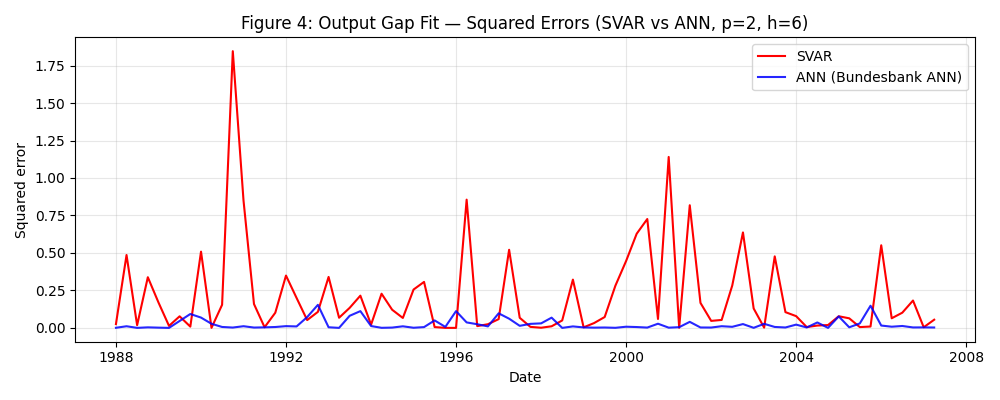

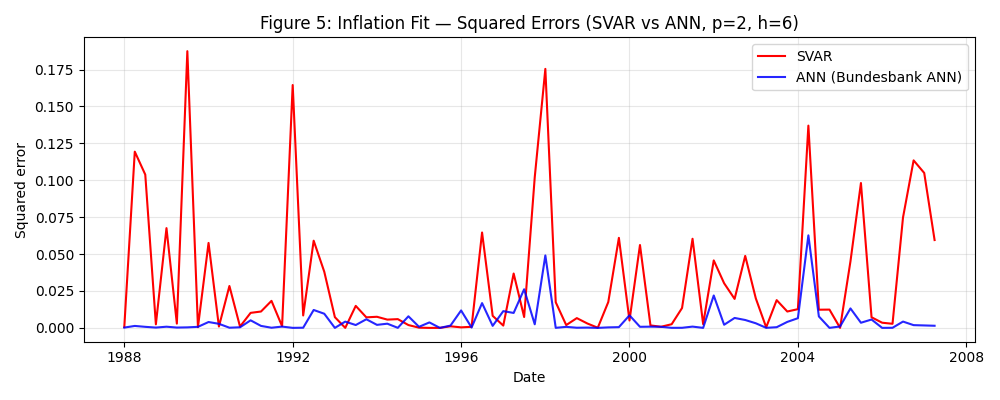

In [30]:
# In-sample squared errors (align to SVAR figure index)
with torch.no_grad():
    y_hat_all = ann_y(Dy["X"]).squeeze().cpu().numpy()
    y_true_all = Dy["y"].squeeze().cpu().numpy()
    se_y_ann = pd.Series((y_true_all - y_hat_all) ** 2, index=Dy["idx"])

# Overlay on Figure 4 (Output Gap) — blue line
fig = le_solver.figure_seven
ax = fig.gca()
for line in list(ax.get_lines()):
    if "ANN" in str(line.get_label()):
        line.remove()
ax.plot(se_y_ann.index.to_timestamp(), se_y_ann.values, color="blue", lw=1.5, alpha=0.85, label="ANN (Bundesbank ANN)")
ax.legend(loc="upper right")
ax.set_title(f"Figure 4: Output Gap Fit — Squared Errors (SVAR vs ANN, p={p}, h=6)")
plt.tight_layout()
plt.show(fig)

# Optional: also overlay inflation on Figure 5
fig_pi = le_solver.figure_eight
ax_pi = fig_pi.gca()
with torch.no_grad():
    pi_hat_all = ann_pi(Dpi["X"]).squeeze().cpu().numpy()
    pi_true_all = Dpi["y"].squeeze().cpu().numpy()
    se_pi_ann = pd.Series((pi_true_all - pi_hat_all) ** 2, index=Dpi["idx"])
for line in list(ax_pi.get_lines()):
    if "ANN" in str(line.get_label()):
        line.remove()
ax_pi.plot(se_pi_ann.index.to_timestamp(), se_pi_ann.values, color="blue", lw=1.5, alpha=0.85, label="ANN (Bundesbank ANN)")
ax_pi.legend(loc="upper right")
ax_pi.set_title(f"Figure 5: Inflation Fit — Squared Errors (SVAR vs ANN, p={p}, h=6)")
plt.tight_layout()
plt.show(fig_pi)

In [ ]:
# Table 3: Economy Fit — Mean Squared Errors (in-sample; SVAR vs ANN)

import numpy as np
import pandas as pd
import torch
from IPython.display import display, Markdown

def _se_series_from_svar_fig(fig):
    ax = fig.gca()
    line = next((ln for ln in ax.get_lines() if str(ln.get_label()).strip() == "SVAR"), None)
    if line is None:
        raise RuntimeError("SVAR line not found on figure.")
    x = pd.to_datetime(line.get_xdata())
    y = pd.Series(line.get_ydata(), index=pd.DatetimeIndex(x)).sort_index()
    return y

# SVAR squared errors from stored figures
se_y_svar = _se_series_from_svar_fig(le_solver.figure_seven)
se_pi_svar = _se_series_from_svar_fig(le_solver.figure_eight)

# ANN squared errors (recompute to ensure alignment)
with torch.no_grad():
    y_hat = ann_y(Dy["X"]).squeeze().cpu().numpy()
    y_true = Dy["y"].squeeze().cpu().numpy()
    se_y_ann = pd.Series((y_true - y_hat) ** 2, index=Dy["idx"].to_timestamp()).sort_index()

    pi_hat = ann_pi(Dpi["X"]).squeeze().cpu().numpy()
    pi_true = Dpi["y"].squeeze().cpu().numpy()
    se_pi_ann = pd.Series((pi_true - pi_hat) ** 2, index=Dpi["idx"].to_timestamp()).sort_index()

# Align ANN to SVAR figure indices (paper’s in-sample window)
se_y_ann_a  = se_y_ann.reindex(se_y_svar.index).dropna()
se_y_svar_a = se_y_svar.reindex(se_y_ann_a.index)

se_pi_ann_a  = se_pi_ann.reindex(se_pi_svar.index).dropna()
se_pi_svar_a = se_pi_svar.reindex(se_pi_ann_a.index)

table_str = fr"""
| Representation | MSE Output Gap           | MSE Inflation             | MSE Total                                        |
|----------------|--------------------------|---------------------------|--------------------------------------------------|
| SVAR           | {se_y_svar_a.mean():.4f} | {se_pi_svar_a.mean():.4f} | {(se_y_svar_a.mean() + se_pi_svar_a.mean()):.4f} |
| ANN            | {se_y_ann_a.mean():.4f}  | {se_pi_ann_a.mean():.4f}  | {(se_y_ann_a.mean() + se_pi_ann_a.mean()):.4f}   |
"""

display(Markdown(table_str))

documents
| Representation | MSE Output Gap | MSE Inflation | MSE Total |
|----------------|----------------|---------------|-----------|
| SVAR           | 0.2115       | 0.0315      | 0.2430 |
| ANN            | 0.0237       | 0.0047      | 0.0285 |
